### Libraries

In [42]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score


sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [22]:
df = pd.read_csv("C:\\Users\\yamsq\\OneDrive - valentinslr\\Documents\\Info B2\\customer_personnality\\marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Nettoyage des données

Retrait des colonnes avec des constantes et l'ID

In [36]:
df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"], inplace=True, errors="ignore")

Gestion de l'âge

In [50]:
df["Age"] = 2026 - df["Year_Birth"]
df.drop(columns=["Year_Birth"], inplace=True)

KeyError: 'Year_Birth'

Retrait des valeurs aberrantes de l'âge

In [ ]:
df = df[df["Age"] <= 100].reset_index(drop=True)
df.head(5)

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,4,7,0,0,0,0,0,0,1,69
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,2,5,0,0,0,0,0,0,0,72
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,10,4,0,0,0,0,0,0,0,61
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,4,6,0,0,0,0,0,0,0,42
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,6,5,0,0,0,0,0,0,0,45


Gérer le niveau de diplôme par un encodage ordinal

In [ ]:
edu_order = [["Basic", "2n Cycle", "Graduation", "Master", "PhD"]]
df["Education"] = OrdinalEncoder(categories=edu_order).fit_transform(df[["Education"]])

In [ ]:
df.head(5)

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,2.0,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,4,7,0,0,0,0,0,0,1,69
1,2.0,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,2,5,0,0,0,0,0,0,0,72
2,2.0,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,10,4,0,0,0,0,0,0,0,61
3,2.0,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,4,6,0,0,0,0,0,0,0,42
4,4.0,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,6,5,0,0,0,0,0,0,0,45


Encodage du statut marital : on observe deux catégories "couple" : together et married. Le reste, c'est des personnes célibataires qui le vivent plus ou moins bien. 
On part sur un mapping pour encoder notre variable de manière binaire.

In [ ]:
marital_map = {
    "Married": 1,
    "Together": 1,
    "Single": 0,
    "Alone": 0,
    "Absurd": 0,
    "YOLO": 0,
    "Divorced": 0,
    "Widow": 0,
}
df["Marital_Status"] = df["Marital_Status"].map(marital_map)


In [ ]:
print(df.head(5))
print(df.shape)

   Education  Marital_Status   Income  Kidhome  Teenhome Dt_Customer  Recency  \
0        2.0               0  58138.0        0         0  04-09-2012       58   
1        2.0               0  46344.0        1         1  08-03-2014       38   
2        2.0               1  71613.0        0         0  21-08-2013       26   
3        2.0               1  26646.0        1         0  10-02-2014       26   
4        4.0               1  58293.0        1         0  19-01-2014       94   

   MntWines  MntFruits  MntMeatProducts  ...  NumStorePurchases  \
0       635         88              546  ...                  4   
1        11          1                6  ...                  2   
2       426         49              127  ...                 10   
3        11          4               20  ...                  4   
4       173         43              118  ...                  6   

   NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  \
0                  7          

Vérification des données manquantes

In [ ]:
df.isna().sum()

Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
Age                     0
dtype: int64

Text(0.7, 630000, 'Outliers 2')

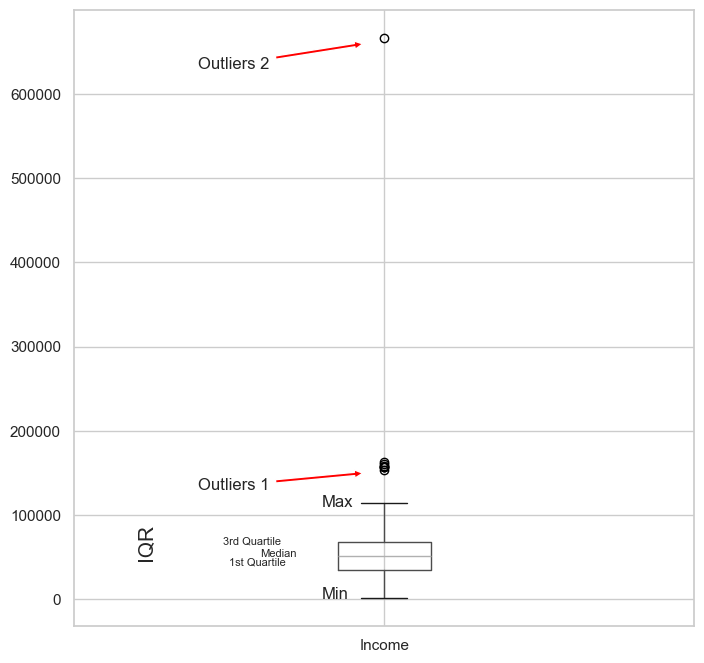

In [ ]:
df.boxplot(column="Income",return_type='axes',figsize=(8,8))

plt.text(x=0.74, y=65000, s="3rd Quartile", size = 8)
plt.text(x=0.8, y=50000, s="Median", size = 8)
plt.text(x=0.75, y=40000, s="1st Quartile", size = 8)
plt.text(x=0.9, y=0, s="Min")
plt.text(x=0.9, y=110000, s="Max")
plt.text(x=0.6, y=50000, s="IQR", rotation=90, size=15)
plt.annotate('Outliers 1', xy = (.97, 150000), xytext = (.7, 130000),
             arrowprops = dict(arrowstyle = 'simple', facecolor = 'red'))
plt.annotate('Outliers 2', xy = (.97, 660000), xytext = (.7, 630000),
             arrowprops = dict(arrowstyle = 'simple', facecolor = 'red'))

In [ ]:
dfHighIncome = df.loc[df.Income > 110000]
dfHighIncome

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
164,4.0,1,157243.0,0,1,01-03-2014,98,20,2,1582,...,0,0,0,0,0,0,0,0,0,53
614,4.0,1,162397.0,1,1,03-06-2013,31,85,1,16,...,1,1,0,0,0,0,0,0,0,50
652,2.0,0,153924.0,0,0,07-02-2014,81,1,1,1,...,0,0,0,0,0,0,0,0,0,51
684,4.0,1,160803.0,0,0,04-08-2012,21,55,16,1622,...,1,0,0,0,0,0,0,0,0,44
1297,3.0,1,157733.0,1,0,04-06-2013,37,39,1,9,...,1,1,0,0,0,0,0,0,0,55
1650,2.0,1,157146.0,0,0,29-04-2013,13,1,0,1725,...,0,1,0,0,0,0,0,0,0,49
1895,4.0,0,113734.0,0,0,28-05-2014,9,6,2,3,...,0,1,0,0,0,0,0,0,0,81
2129,4.0,1,156924.0,0,0,29-08-2013,85,2,1,2,...,0,0,0,0,0,0,0,0,0,77
2230,2.0,1,666666.0,1,0,02-06-2013,23,9,14,18,...,3,6,0,0,0,0,0,0,0,49


In [ ]:
df = df.drop(df[df.Income > 110000].index)
df.shape

(2228, 26)

In [ ]:
df = df.dropna()
df.shape

(2204, 26)

In [ ]:
df.isnull().sum()

Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Age                    0
dtype: int64

Plus aucune valeur manquante et les outliers du revenu ont été éliminés. On notera que ces outliers avaient pour la moitié un doctorat et l'autre à peine le bac : à se demander la valeur des études supérieures Licence / Master... eheh

In [47]:
df.boxplot(column="Income",return_type='axes',figsize=(8,8))

plt.text(x=0.74, y=65000, s="3rd Quartile", size = 8)
plt.text(x=0.8, y=50000, s="Median", size = 8)
plt.text(x=0.75, y=40000, s="1st Quartile", size = 8)
plt.text(x=0.9, y=0, s="Min")
plt.text(x=0.9, y=110000, s="Max")
plt.text(x=0.6, y=50000, s="IQR", rotation=90, size=15)
plt.annotate('Outliers 1', xy = (.97, 150000), xytext = (.7, 130000),
             arrowprops = dict(arrowstyle = 'simple', facecolor = 'red'))
plt.annotate('Outliers 2', xy = (.97, 660000), xytext = (.7, 630000),
             arrowprops = dict(arrowstyle = 'simple', facecolor = 'red'))

Text(0.7, 630000, 'Outliers 2')

In [45]:
corrDf = df.corr(numeric_only=True)
corrDf

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
Education,1.000000,-0.012625,0.172242,-0.052156,0.138923,-0.013194,0.216817,-0.077813,0.042014,-0.102448,...,0.096243,-0.049077,0.004239,0.063771,0.033669,-0.001739,0.024516,-0.038867,0.100678,0.193202
Marital_Status,-0.012625,1.000000,-0.010597,0.026379,0.031923,-0.000482,-0.007967,-0.027344,-0.032454,-0.018551,...,0.004715,0.004735,-0.018720,-0.006545,0.018674,0.009204,-0.002911,0.000962,-0.150528,0.005056
Income,0.172242,-0.010597,1.000000,-0.531746,0.043848,0.008620,0.733335,0.539904,0.705043,0.553858,...,0.691569,-0.647657,-0.010819,0.234135,0.417629,0.346312,0.110596,-0.027414,0.175842,0.210475
Kidhome,-0.052156,0.026379,-0.531746,1.000000,-0.040569,0.011319,-0.499787,-0.374707,-0.446069,-0.390245,...,-0.507664,0.448223,0.015794,-0.162731,-0.205264,-0.174868,-0.082181,0.036996,-0.078582,-0.237581
Teenhome,0.138923,0.031923,0.043848,-0.040569,1.000000,0.013306,0.002409,-0.177234,-0.267578,-0.206716,...,0.046606,0.128726,-0.043352,0.037749,-0.190920,-0.145889,-0.015858,0.007594,-0.155411,0.364198
Recency,-0.013194,-0.000482,0.008620,0.011319,0.013306,1.000000,0.015922,-0.005297,0.025685,0.000757,...,-0.000666,-0.019056,-0.032519,0.017488,0.000158,-0.021271,-0.001465,0.005701,-0.200773,0.015531
MntWines,0.216817,-0.007967,0.733335,-0.499787,0.002409,0.015922,1.000000,0.384801,0.592999,0.395807,...,0.639231,-0.330422,0.060598,0.373022,0.472709,0.351308,0.206221,-0.036754,0.245443,0.165448
MntFruits,-0.077813,-0.027344,0.539904,-0.374707,-0.177234,-0.005297,0.384801,1.000000,0.568013,0.592481,...,0.458931,-0.425312,0.014054,0.006000,0.208559,0.192008,-0.010180,-0.003161,0.122229,0.013731
MntMeatProducts,0.042014,-0.032454,0.705043,-0.446069,-0.267578,0.025685,0.592999,0.568013,1.000000,0.595582,...,0.517081,-0.544463,0.021132,0.096716,0.389237,0.325264,0.045808,-0.020956,0.248720,0.042277
MntFishProducts,-0.102448,-0.018551,0.553858,-0.390245,-0.206716,0.000757,0.395807,0.592481,0.595582,1.000000,...,0.456731,-0.454279,-0.000918,0.015428,0.194325,0.261340,0.002058,-0.019330,0.107292,0.041520


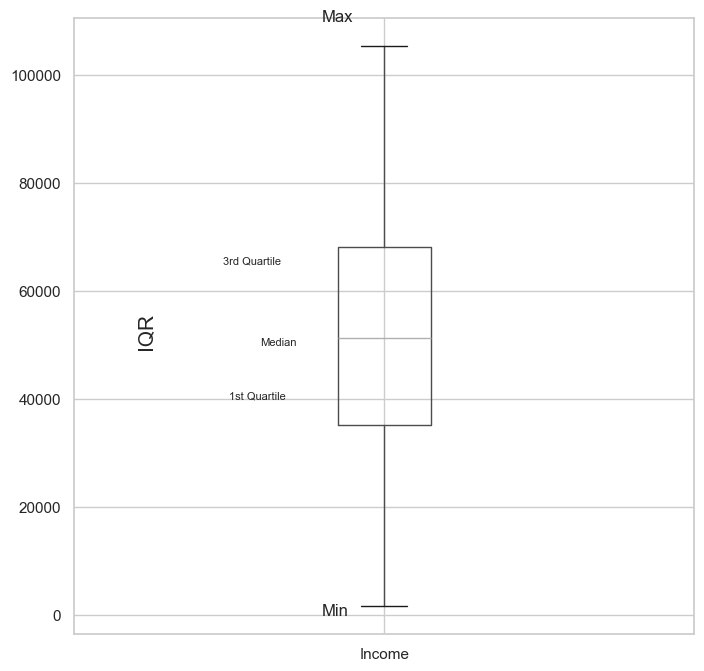

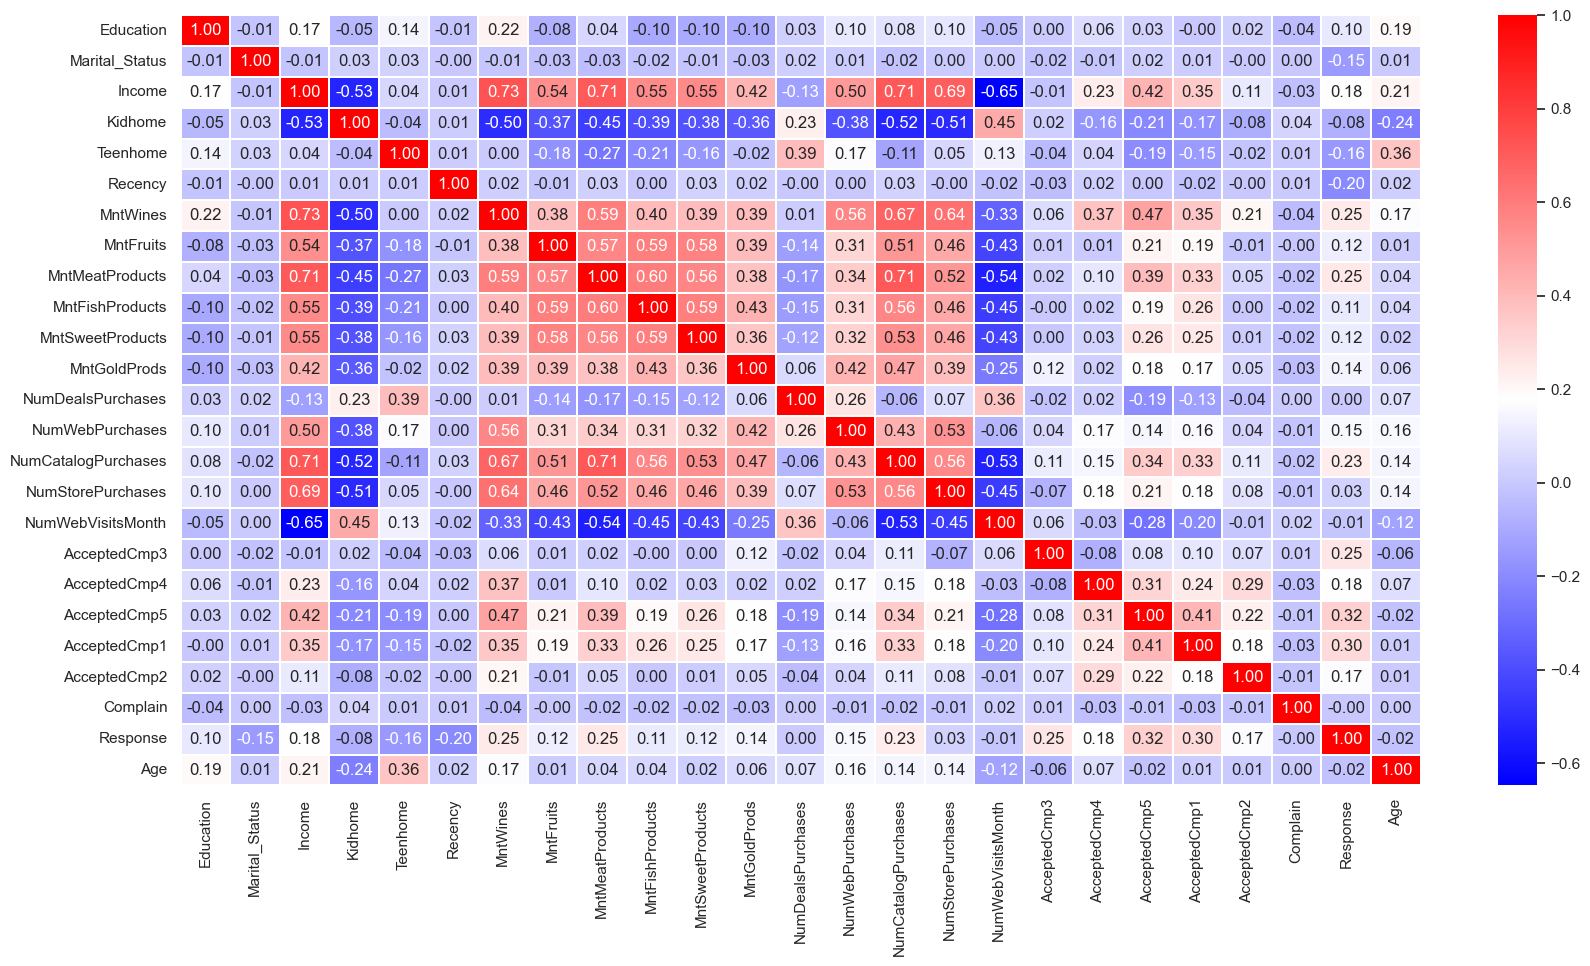

In [48]:
fig,ax = plt.subplots(figsize=(20, 10))
sns.heatmap(corrDf, ax=ax, annot=True, linewidths=0.05, fmt= '.2f',cmap="bwr")
plt.show()

Le revenu (Income) est fortement corrélé aux dépenses en vin (MntWines, r = 0,73), ce qui indique que les clients aux revenus les plus élevés dépensent davantage en vin.

Le revenu (Income) est également fortement corrélé au nombre d'achats sur catalogue (NumCatalogPurchases, r = 0,71), suggérant que les clients les plus aisés utilisent davantage ce canal d'achat.

Les dépenses en produits carnés (MntMeatProducts) sont fortement corrélées au nombre d'achats sur catalogue (NumCatalogPurchases, r = 0,71), ce qui montre que les acheteurs utilisant le catalogue achètent davantage de viande.

Le revenu (Income) est fortement corrélé au nombre d'achats en magasin (NumStorePurchases, r = 0,69), indiquant que les clients disposant d'un revenu élevé réalisent plus d'achats en boutique.

Les dépenses en vin (MntWines) sont fortement corrélées au nombre d'achats sur catalogue (NumCatalogPurchases, r = 0,67), ce qui suggère que les amateurs de vin privilégient souvent le catalogue.

Le revenu (Income) est fortement négativement corrélé au nombre de visites mensuelles du site web (NumWebVisitsMonth, r = -0,65), indiquant que les clients les plus aisés consultent moins souvent le site, probablement parce qu'ils achètent plus efficacement ou via d'autres canaux.

Les dépenses en vin (MntWines) sont fortement corrélées au nombre d'achats en magasin (NumStorePurchases, r = 0,64), ce qui montre que les gros consommateurs de vin effectuent davantage d'achats en magasin.

Les dépenses en produits carnés (MntMeatProducts) sont fortement corrélées aux dépenses en produits de la mer (MntFishProducts, r = 0,60), suggérant que les clients qui dépensent beaucoup dans une catégorie alimentaire premium dépensent également dans les autres.

Les dépenses en vin (MntWines) sont modérément à fortement corrélées aux dépenses en produits carnés (MntMeatProducts, r = 0,59), traduisant un profil de clients ayant des dépenses élevées sur plusieurs catégories alimentaires.

Le nombre d'enfants au foyer (Kidhome) est fortement négativement corrélé au revenu (Income, r = -0,53), ce qui indique que les foyers avec davantage d'enfants présentent en moyenne des revenus plus faibles dans ce jeu de données.

## Intéret de la matrice de confusion ici
La matrice de corrélation a été dressée comme base de réflexion pour déterminer le k.
On peut déjà être sûr qu'il existe un k = 2 (riche vs pauvre) mais il serait hyper réducteur.

Mais on sait déjà que cet axe de catégorisation existe : 
# 1. Niveau de richesse / consommation globale (très probable)

Revenu élevé

Dépenses importantes dans toutes les catégories (MntWines, MntMeatProducts, MntFishProducts, etc.)

Beaucoup d'achats catalogue et magasin

Peu de visites du site

Peu d'enfants

VS

Revenu plus faible

Faibles dépenses

Peu d'achats

Beaucoup de visites du site

Davantage d'enfants

# 2. Mode de consommation 
Au vu des corrélations entre elles des modes de consommation (side, catalogue, en boutique) et avec les types d'achats (notamment vin et catalogue r=.73 ), on peut aussi imaginer un axe de catégorisation selon le mode de consommation, nous ramenant déjà à k=3
On observe notamment :

NumCatalogPurchases

NumStorePurchases

NumWebPurchases

NumWebVisitsMonth

On peut imaginer des profils comme :

Clients magasin

Clients catalogue

Clients web

Visiteurs web qui achètent peu

Par exemple, NumWebVisitsMonth est négativement corrélé aux achats, ce qui peut représenter des personnes qui consultent beaucoup mais convertissent peu.

# 3. Sensibilité aux campagnes marketing

Les variables

AcceptedCmp1

AcceptedCmp2

AcceptedCmp3

AcceptedCmp4

AcceptedCmp5

Response

sont relativement corrélées entre elles.

On peut donc distinguer :

clients très réceptifs aux campagnes,

clients qui n'acceptent quasiment jamais les offres.

C'est un axe marketing intéressant, assez indépendant du revenu.

# 4. Composition familiale

Les variables

Kidhome

Teenhome

sont peu corrélées entre elles (≈ -0,04), ce qui signifie qu'elles apportent chacune une information différente.

On peut donc voir apparaître des profils :

jeunes couples sans enfant,

familles avec jeunes enfants,

familles avec adolescents.

Ces profils auront probablement des comportements d'achat différents.

# 5. Préférences produits

Les montants dépensés sont corrélés, mais pas parfaitement.

Par exemple :

certains clients dépensent énormément en vin ;

d'autres davantage en viande ;

certains achètent beaucoup de produits premium (MntGoldProds).


Le clustering peut donc révéler :

amateurs de vin,

consommateurs généralistes,

acheteurs orientés produits premium.

Ces profils sont souvent moins visibles avec une simple matrice de corrélation.

## Ce que cela implique pour le choix de K
On peut s'attendre à un K=4 à 5 (dimensions significatives guidant le nombre de persona)

| Cluster        | Description                                           |
| -------------- | ----------------------------------------------------- |
| 1              | Clients aisés, gros consommateurs, fidèles            |
| 2              | Clients modestes, peu d'achats, familles avec enfants |
| 3              | Clients très actifs sur le web mais faibles acheteurs |
| 4              | Clients très réceptifs aux campagnes marketing        |
| 5              | Clients orientés produits premium / vin               |

La matrice de confusion permet de poser des hypothèses qui sont à vérifier par les tests classiques : méthode du coude ou test de silhouette, que nous allons mener dès à présent.



# Détermination par méthode quantitative du nombre de cluster K

A la réflexion, on a plusieurs variables qui racontent la même histoire, au niveau de la consommation : toutes les consommations de produits de luxe racontent l'histoire de la richesse des personnes.
Il faut donc appliquer une PCA afin de ne plus compter cette histoire plusieurs fois dans nos calculs.

### PCA

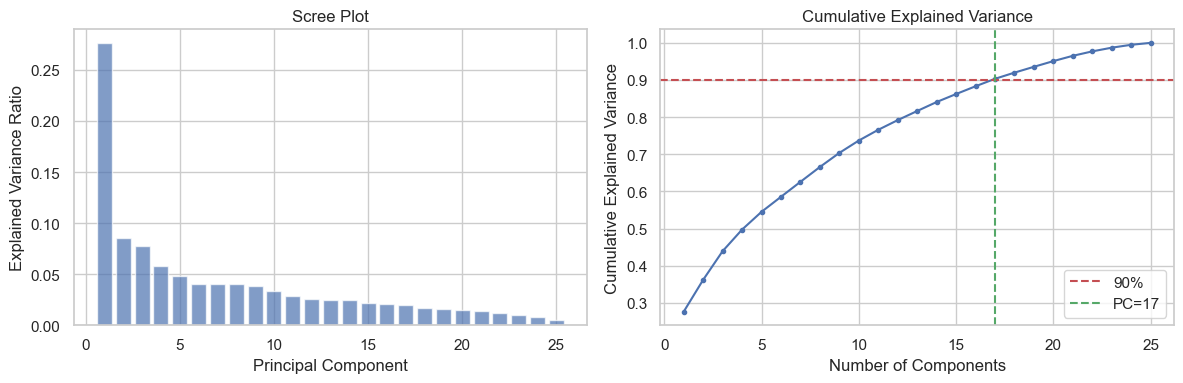

17 components reach 90% variance (out of 25 features)


In [54]:
X = df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.searchsorted(cumvar, 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    alpha=0.7,
)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")
axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker="o", markersize=3)
axes[1].axhline(0.90, color="r", linestyle="--", label="90%")
axes[1].axvline(n_90, color="g", linestyle="--", label=f"PC={n_90}")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"{n_90} components reach 90% variance (out of {X.shape[1]} features)")

pca_km = PCA(n_components=n_90, random_state=RANDOM_STATE)
X_pca_km = pca_km.fit_transform(X_scaled)

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_scaled)

In [55]:
import pandas as pd


valeur = "04-09-2012"

for col in df.columns:
    if (df[col].astype(str) == valeur).any():
        print(f"Colonne trouvée : {col}")
        print(df[col])
        break

In [56]:
df = df.drop(columns=["Dt_Customer"])

KeyError: "['Dt_Customer'] not found in axis"

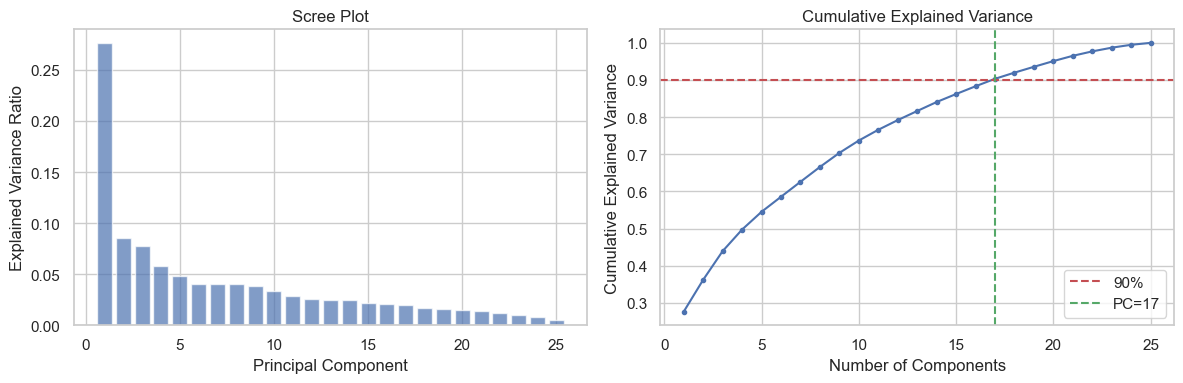

17 components reach 90% variance (out of 25 features)


In [ ]:
X = df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.searchsorted(cumvar, 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    alpha=0.7,
)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")
axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker="o", markersize=3)
axes[1].axhline(0.90, color="r", linestyle="--", label="90%")
axes[1].axvline(n_90, color="g", linestyle="--", label=f"PC={n_90}")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"{n_90} components reach 90% variance (out of {X.shape[1]} features)")

pca_km = PCA(n_components=n_90, random_state=RANDOM_STATE)
X_pca_km = pca_km.fit_transform(X_scaled)

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_scaled)

17 composants ?! le gain est marginal...
Cependant, sur le scree plot, on observe que la PC1 est très domainante et qu'on a un effet de plateau qui arrive assez vite entre 5 et 8.
C'est surement l'effet de la richesse.
Après 10, ça chute.

Je pense pouvoir prendre 8 dimensions aisément. voir 10, et garder bien 70% de la variance expliquée.

In [57]:
loadings = pd.DataFrame(
    pca_full.components_[:8].T,
    index=df.columns,
    columns=[f"PC{i+1}" for i in range(8)]
).round(3).sort_values('PC1', ascending=False)

display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Income,0.337,0.090,-0.025,-0.128,0.049,0.012,0.020,0.010
NumCatalogPurchases,0.319,0.012,-0.013,0.045,0.062,0.075,-0.013,-0.075
MntMeatProducts,0.311,-0.132,-0.027,0.004,0.047,-0.013,-0.006,-0.018
MntWines,0.302,0.195,0.163,-0.027,-0.052,-0.007,0.002,-0.040
NumStorePurchases,0.281,0.179,-0.132,-0.015,-0.091,-0.087,0.018,0.079
MntFishProducts,0.268,-0.160,-0.185,0.114,-0.037,-0.042,0.006,0.043
MntSweetProducts,0.263,-0.140,-0.158,0.106,-0.082,-0.036,-0.001,0.034
MntFruits,0.259,-0.148,-0.187,0.132,-0.012,-0.044,-0.004,0.065
MntGoldProds,0.215,0.049,-0.098,0.321,-0.062,0.067,-0.043,-0.111
NumWebPurchases,0.212,0.332,-0.029,0.277,-0.096,-0.044,0.023,-0.000


c:\Users\yamsq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\yamsq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\yamsq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\yamsq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

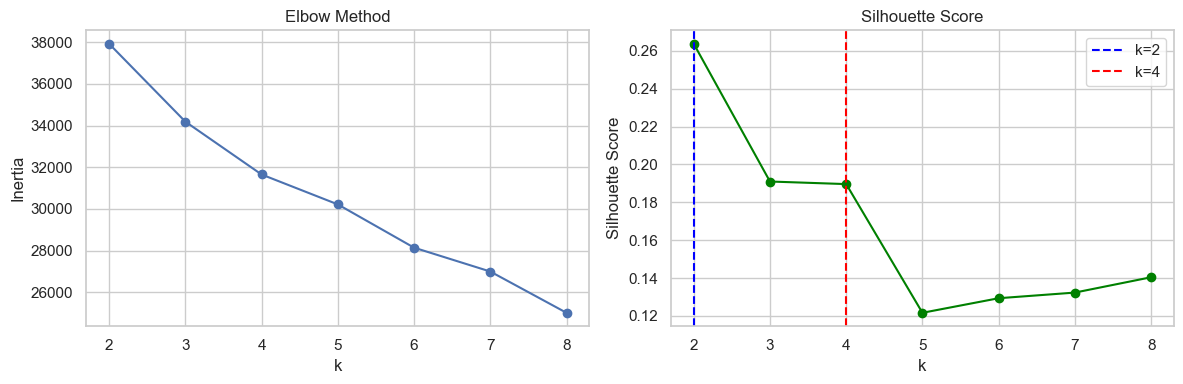

  k=2  silhouette=0.2637
  k=3  silhouette=0.1910
  k=4  silhouette=0.1896
  k=5  silhouette=0.1216
  k=6  silhouette=0.1293
  k=7  silhouette=0.1323
  k=8  silhouette=0.1404


In [58]:
# Elbow + silhouette
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca_km)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_pca_km, labels, sample_size=1000, random_state=RANDOM_STATE)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")

axes[1].plot(K_range, silhouettes, marker="o", color="green")
for k_mark, color in [(2, "blue"), (4, "red")]:
    axes[1].axvline(k_mark, color=color, linestyle="--", label=f"k={k_mark}")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score"); axes[1].legend()

plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouettes):
    print(f"  k={k}  silhouette={s:.4f}")

c:\Users\yamsq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


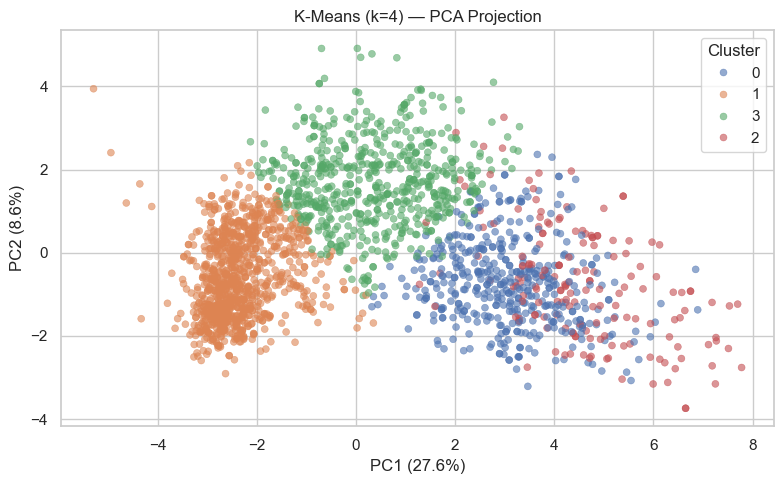

Cluster
0    440
1    991
2    168
3    605
Name: count, dtype: int64


In [59]:
K4 = 4
km4 = KMeans(
    n_clusters=K4,
    random_state=RANDOM_STATE,
    n_init=10
)

labels4 = km4.fit_predict(X_pca_km)
plot_df = pd.DataFrame({
    "PC1": X_pca2[:, 0],
    "PC2": X_pca2[:, 1],
    "Cluster": labels4.astype(str)
})

# plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    alpha=0.6,
    s=25,
    edgecolor=None
)

plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.title("K-Means (k=4) — PCA Projection")

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# cluster size
print(
    pd.Series(labels4, name="Cluster")
      .value_counts()
      .sort_index()
)

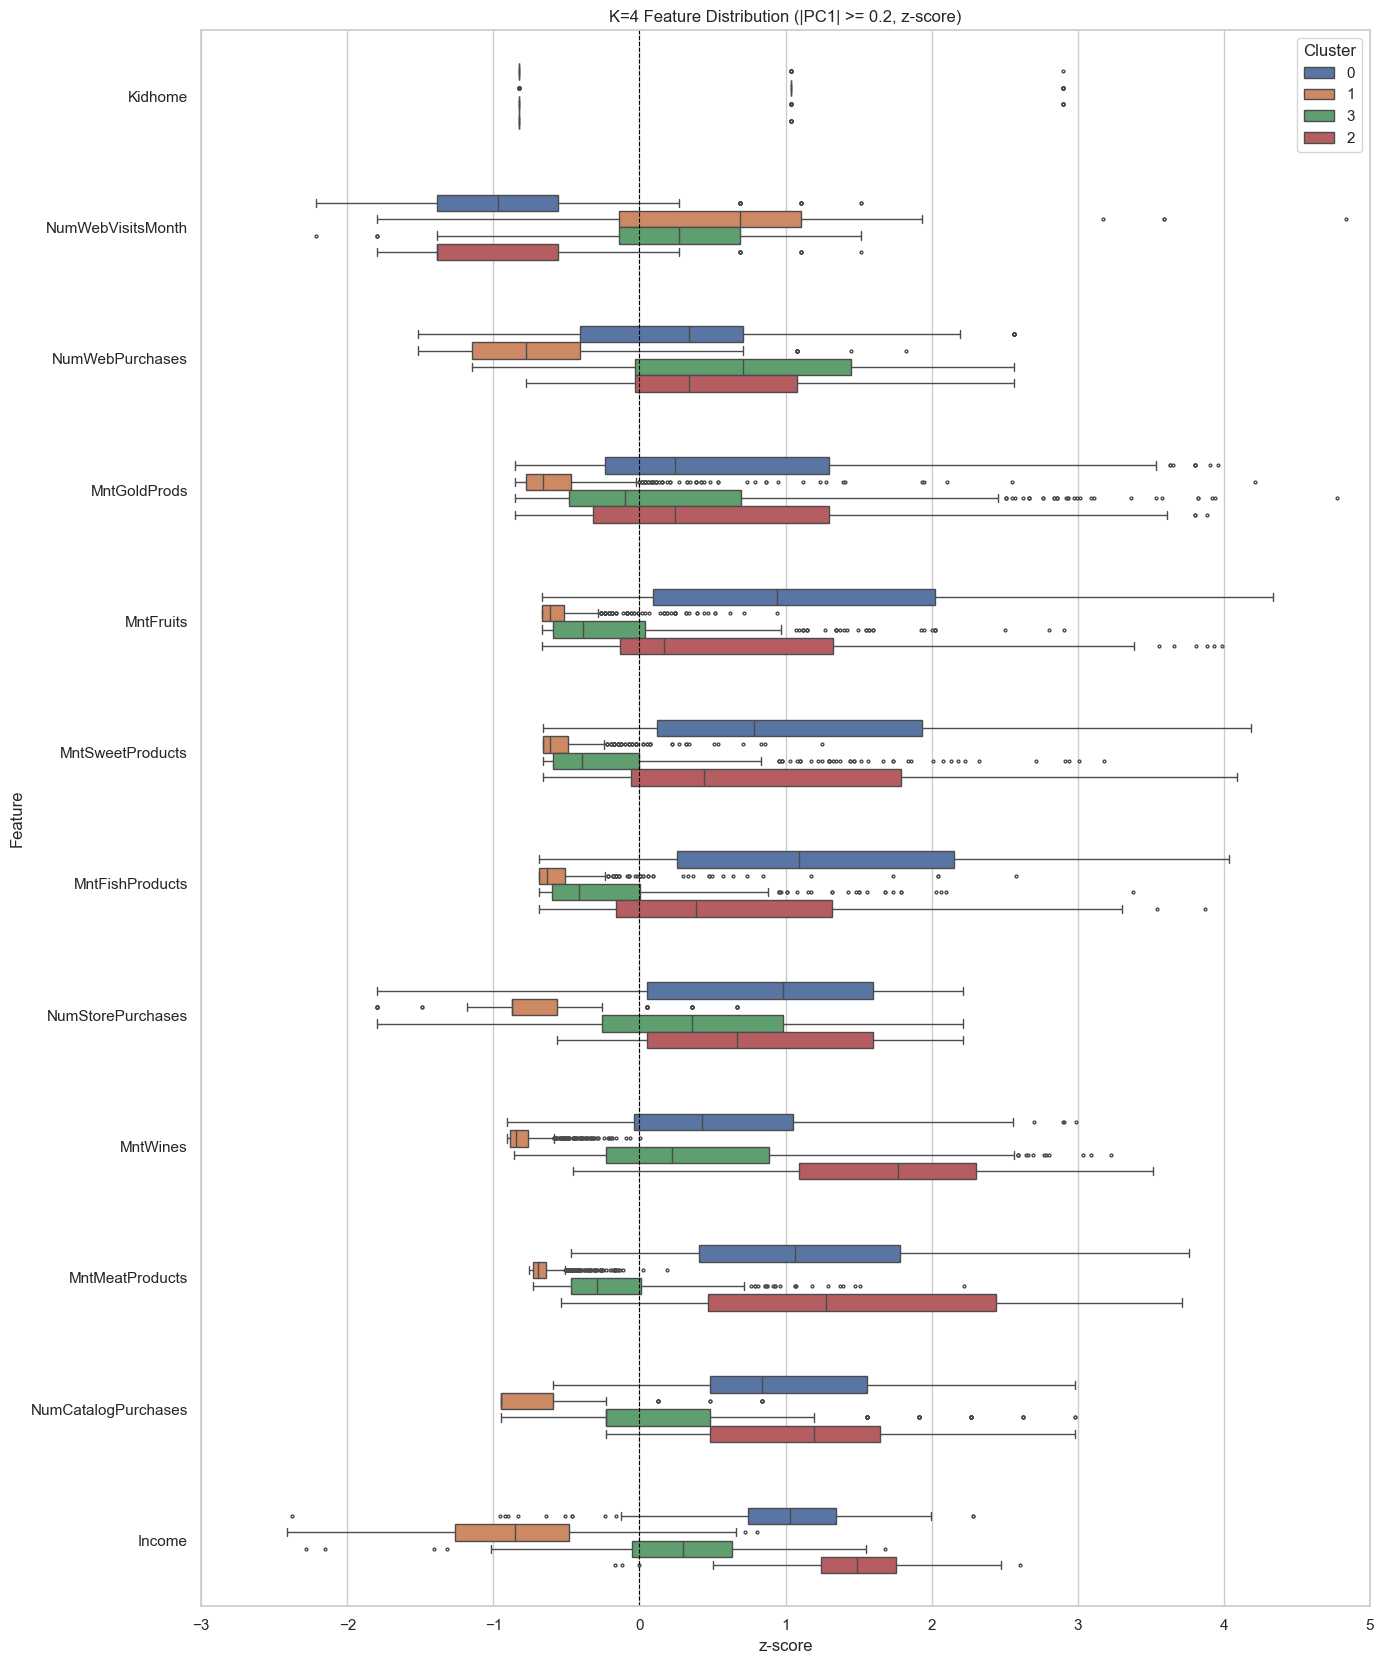

In [60]:
pc1_loadings = pd.Series(pca_full.components_[0], index=df.columns)
key_features = pc1_loadings[pc1_loadings.abs() >= 0.2].sort_values().index.tolist()
plot_df4 = df[key_features].copy()
plot_df4["Cluster"] = labels4.astype(str)
plot_df4[key_features] = StandardScaler().fit_transform(plot_df4[key_features])
long_df4 = plot_df4.melt(
    id_vars="Cluster", value_vars=key_features, var_name="Feature", value_name="z-score"
)

fig, ax = plt.subplots(figsize=(14, len(key_features) * 1.4))
sns.boxplot(
    data=long_df4,
    y="Feature",
    x="z-score",
    hue="Cluster",
    ax=ax,
    orient="h",
    order=key_features,
    width=0.5,
    fliersize=2,
)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_title("K=4 Feature Distribution (|PC1| >= 0.2, z-score)")
ax.legend(title="Cluster")
ax.set_xlim(-3, 5)
plt.tight_layout()
plt.show()

# Profiling

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.40,0.60,72272.84,0.05,0.23,49.48,498.16,73.07,424.46,107.11,...,8.52,2.94,0.06,0.02,0.00,0.11,0.00,0.01,0.17,58.19
1,2.30,0.64,33715.84,0.81,0.42,49.03,38.29,4.98,22.85,7.58,...,3.17,6.54,0.07,0.01,0.00,0.00,0.00,0.01,0.10,53.92
2,2.58,0.68,81917.18,0.05,0.13,49.65,877.54,55.01,468.50,76.48,...,8.24,3.02,0.14,0.39,0.95,0.45,0.12,0.01,0.58,56.18
3,2.73,0.67,57418.93,0.24,0.95,48.52,447.15,19.65,126.27,26.05,...,7.54,5.76,0.06,0.13,0.00,0.03,0.01,0.01,0.10,61.71


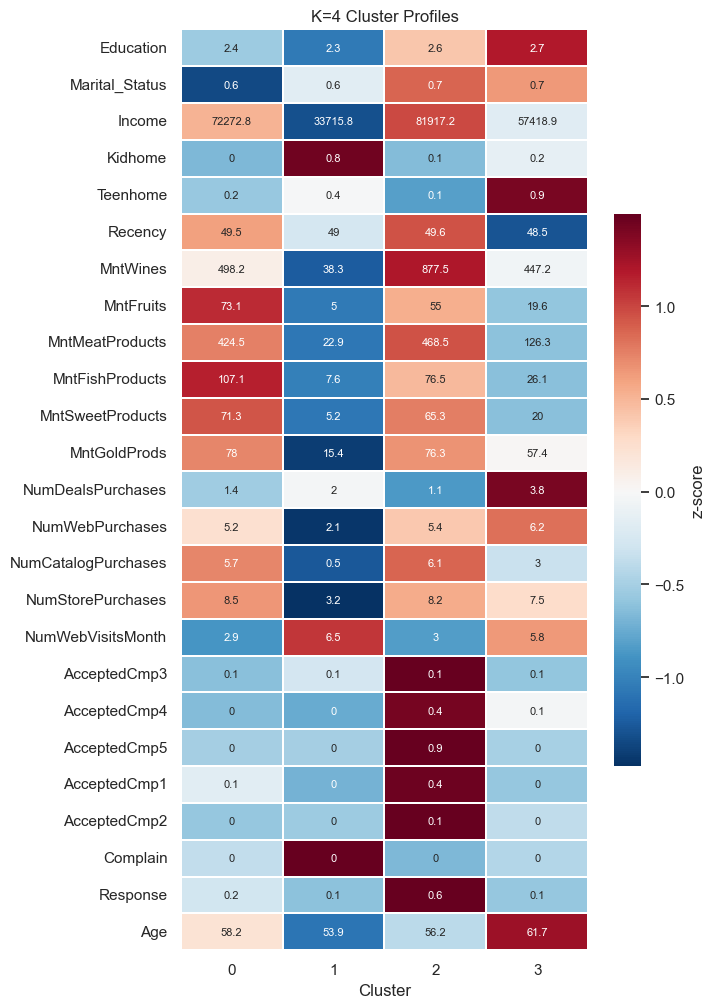

In [61]:
df4 = df.drop(columns=["Cluster"], errors="ignore").copy()
df4["Cluster"] = labels4
profile_cols = [c for c in df4.columns if c != "Cluster"]
centers4 = df4.groupby("Cluster")[profile_cols].mean()
display(centers4.round(2))

centers4_z = (centers4 - centers4.mean()) / (centers4.std() + 1e-9)
fig, ax = plt.subplots(figsize=(max(4, K4 * 1.8), len(profile_cols) * 0.35 + 1.5))
sns.heatmap(
    centers4_z.T,
    cmap="RdBu_r",
    center=0,
    annot=centers4.T.round(1),
    fmt="g",
    annot_kws={"size": 8},
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "z-score", "shrink": 0.6},
)
ax.set_title("K=4 Cluster Profiles")
plt.tight_layout()
plt.show()

| Variable              | Cluster 0 |   Cluster 1 |   Cluster 2 | Cluster 3 |
| --------------------- | --------: | ----------: | ----------: | --------: |
| Revenu (€)            |    72 273 |      33 716 |      81 917 |    57 418 |
| Vin (€)               |       498 |          38 |         878 |       447 |
| Viande (€)            |       425 |          23 |         469 |       126 |
| Achats web            |       5,2 |         2,1 |         5,4 |       6,2 |
| Achats catalogue      |       5,7 |         0,5 |         6,1 |       3,0 |
| Visites web/mois      |       2,9 |         6,5 |         3,0 |       5,8 |
| Réponse aux campagnes |    Faible | Très faible | Très élevée |    Faible |


| Cluster | Persona                 | Caractéristique dominante                                      |
| ------- | ----------------------- | -------------------------------------------------------------- |
| **0**   | Clients premium fidèles | Dépensent beaucoup dans toutes les catégories                  |
| **1**   | Visiteurs prudents      | Faible revenu, faible consommation, navigation importante      |
| **2**   | Ambassadeurs premium    | Très riches, très gros acheteurs, très réceptifs aux campagnes |
| **3**   | Acheteurs opportunistes | Revenus intermédiaires, promotions, achats web                 |
